# Reconhecimento de Dígitos Manuscritos — Rede Neural com 98% de Acurácia

**Competição:** https://www.kaggle.com/competitions/digit-recognizer  
**Autora:** Juliana Burato  
**Algoritmo:** MLP (Multilayer Perceptron) com Data Augmentation  
**Acurácia no Kaggle:** 98.089%

---

## Descrição

Classificação de dígitos manuscritos (0–9) do dataset MNIST, disponibilizado pela competição [Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer) do Kaggle.  
Cada imagem é representada por 784 valores de pixel (28×28), com intensidade de 0 a 255.

## Fluxo do Projeto

```
Kaggle API → train.csv / test.csv
    → Análise Exploratória (EDA)
    → Pré-processamento: normalização + reshape (28×28×1) + one-hot encoding
    → Data Augmentation
    → MLP: Dense(256) → Dense(128) → Dense(64) → Softmax(10)
    → Treinamento com Early Stopping + ReduceLROnPlateau
    → Avaliação: matriz de confusão + relatório por classe
    → submission.csv
```

## 1. Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Fixar seeds para reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow {tf.__version__}')

TensorFlow 2.20.0


## 2. Carregamento dos Dados

Faça upload dos arquivos `train.csv` e `test.csv` diretamente no painel lateral do Colab  
(ícone de pasta → upload) antes de executar a célula abaixo.

In [5]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Treino: {train.shape[0]:,} amostras, {train.shape[1]} colunas')
print(f'Teste:  {test.shape[0]:,} amostras, {test.shape[1]} colunas')
print()

train.head(3)

Treino: 42,000 amostras, 785 colunas
Teste:  28,000 amostras, 784 colunas



,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Análise Exploratória (EDA)

Antes de modelar, é importante entender os dados:
- **Balanceamento:** verificar se há classes sub-representadas (influencia a escolha da métrica)
- **Visualização:** identificar variações de escrita e possíveis confusões entre classes (ex: 4↔9, 3↔8)
- **Valores de pixel:** confirmar o intervalo esperado (0–255) e a ausência de valores ausentes

Valores ausentes no treino: 0
Intervalo dos pixels: 0 – 255



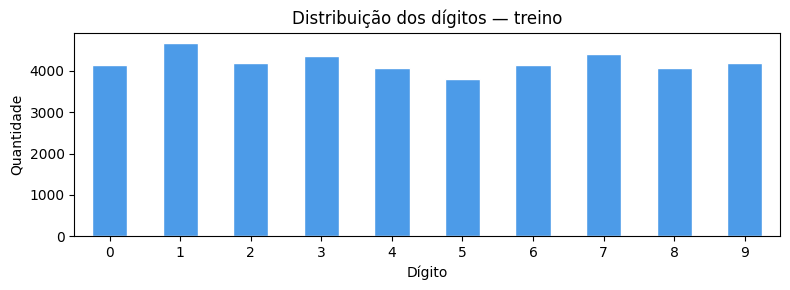

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188


In [6]:
# Verificar valores ausentes e tipo dos dados
print('Valores ausentes no treino:', train.isnull().sum().sum())
print('Intervalo dos pixels:', train.iloc[:, 1:].min().min(), '–', train.iloc[:, 1:].max().max())
print()

# Distribuição das classes
# Dataset balanceado (~4.200 exemplos por dígito) — sem necessidade de oversampling
plt.figure(figsize=(8, 3))
train['label'].value_counts().sort_index().plot(
    kind='bar', color='#4C9BE8', edgecolor='white'
)
plt.title('Distribuição dos dígitos — treino')
plt.xlabel('Dígito')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(train['label'].value_counts().sort_index().to_string())

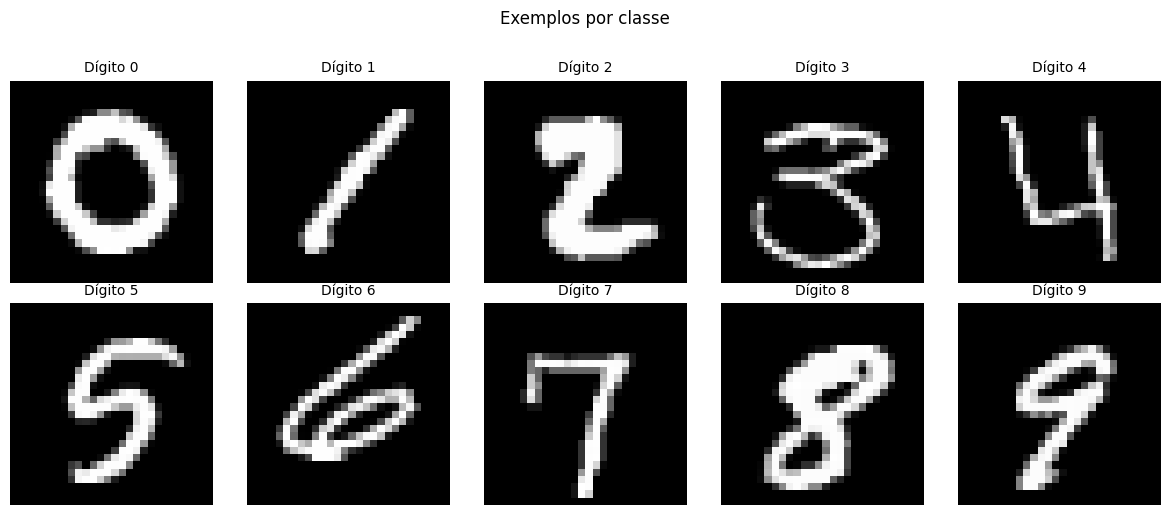

In [7]:
# Visualizar um exemplo de cada dígito
# Útil para identificar variações de escrita e possíveis confusões visuais entre classes
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digito, ax in zip(range(10), axes.flat):
    idx = train[train['label'] == digito].index[0]
    ax.imshow(train.iloc[idx, 1:].values.reshape(28, 28), cmap='gray')
    ax.set_title(f'Dígito {digito}', fontsize=10)
    ax.axis('off')
plt.suptitle('Exemplos por classe', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4. Pré-processamento

Três transformações são aplicadas antes do treinamento:

| Etapa | Transformação | Motivo |
|---|---|---|
| Normalização | Pixels ÷ 255 → [0.0, 1.0] | Gradientes mais estáveis durante o backpropagation |
| Reshape | `(n, 784)` → `(n, 28, 28, 1)` | Preserva a estrutura espacial da imagem |
| One-hot encoding | Labels inteiros → vetores binários de dim. 10 | Formato exigido pela loss `categorical_crossentropy` |

In [8]:
X            = train.drop('label', axis=1).values
y            = train['label'].values
X_test_final = test.values

# Normalização e reshape
X            = X.astype('float32').reshape(-1, 28, 28, 1) / 255.0
X_test_final = X_test_final.astype('float32').reshape(-1, 28, 28, 1) / 255.0

# One-hot encoding: converte o label inteiro em vetor binário
# Ex: classe 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_cat = keras.utils.to_categorical(y, num_classes=10)

print(f'X (treino):  {X.shape}')
print(f'y (treino):  {y_cat.shape}')
print(f'X (teste):   {X_test_final.shape}')

X (treino):  (42000, 28, 28, 1)
y (treino):  (42000, 10)
X (teste):   (28000, 28, 28, 1)


In [9]:
# Divisão treino/validação (80/20)
# A validação usa imagens originais, sem augmentation, para avaliação mais realista
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

print(f'Treino:    {X_tr.shape[0]:,} amostras')
print(f'Validação: {X_val.shape[0]:,} amostras')

Treino:    33,600 amostras
Validação: 8,400 amostras


## 5. Data Augmentation

O Data Augmentation gera variações sintéticas das imagens de treino durante o treinamento,  
expondo o modelo a diferentes formas de escrita sem precisar de novos dados reais.

As transformações foram escolhidas para simular variações naturais da escrita manual,  
sem distorcer a identidade do dígito:

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `rotation_range` | 10° | Simula inclinação natural da escrita |
| `zoom_range` | 10% | Simula variação de tamanho entre escritores |
| `width_shift_range` | 10% | Simula deslocamento horizontal |
| `height_shift_range` | 10% | Simula deslocamento vertical |

> **Nota:** espelhamento horizontal e rotações acima de 15° não são aplicados —  
> alterariam a identidade do dígito (ex: 6 ↔ 9, 2 invertido).

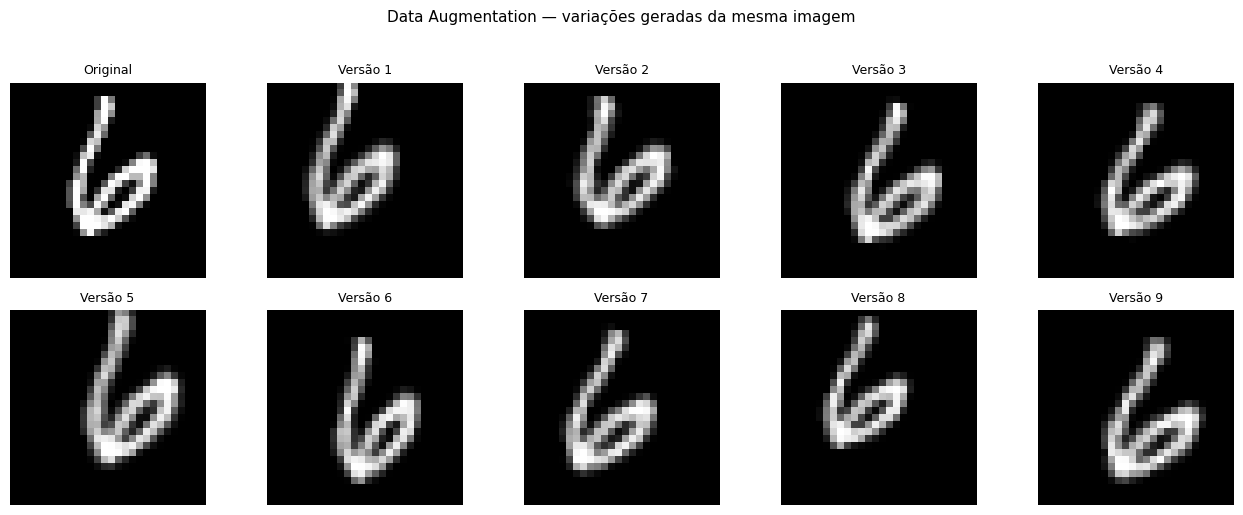

In [10]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
)
datagen.fit(X_tr)

# Visualizar o efeito do augmentation sobre uma mesma imagem
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
axes[0][0].imshow(X_tr[0].reshape(28, 28), cmap='gray')
axes[0][0].set_title('Original', fontsize=9)
axes[0][0].axis('off')

gen = datagen.flow(X_tr[0:1], batch_size=1)
posicoes = [(0,1),(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3),(1,4)]
for i, (l, c) in enumerate(posicoes):
    axes[l][c].imshow(next(gen)[0].reshape(28, 28), cmap='gray')
    axes[l][c].set_title(f'Versão {i+1}', fontsize=9)
    axes[l][c].axis('off')

plt.suptitle('Data Augmentation — variações geradas da mesma imagem', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 6. Arquitetura — MLP

```
Input (28×28×1)
    → Flatten (784)
    → Dense(256) + BatchNorm + ReLU + Dropout(0.3)
    → Dense(128) + BatchNorm + ReLU + Dropout(0.3)
    → Dense(64)  + BatchNorm + ReLU + Dropout(0.2)
    → Dense(10)  + Softmax
```

| Componente | Função |
|---|---|
| **Flatten** | Converte a imagem 28×28×1 em vetor de 784 valores |
| **Dense** | Camada totalmente conectada — aprende combinações lineares das entradas |
| **BatchNormalization** | Normaliza as ativações de cada camada, estabilizando e acelerando o treino |
| **Dropout** | Desativa neurônios aleatoriamente durante o treino para evitar overfitting |
| **Softmax** | Converte os logits da última camada em distribuição de probabilidade (soma = 1) |

> O Dropout decrescente (0.3 → 0.3 → 0.2) reflete que camadas mais profundas,  
> por já trabalharem com representações mais abstratas, precisam de menos regularização.

In [11]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax'),
])

model.compile(
    optimizer='adam',                 # Adam adapta o learning rate individualmente por parâmetro
    loss='categorical_crossentropy',  # Loss padrão para classificação multiclasse com one-hot
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

## 7. Treinamento

Dois callbacks controlam o treinamento automaticamente:

- **EarlyStopping:** interrompe o treino se `val_accuracy` não melhorar por 10 épocas consecutivas  
  e restaura os pesos da melhor época (`restore_best_weights=True`)
- **ReduceLROnPlateau:** reduz o learning rate por fator 0,5 após 5 épocas sem melhora,  
  evitando que o modelo fique preso em mínimos locais

In [12]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    verbose=1
)

# datagen.flow gera batches com augmentation em tempo real durante o treino
# A validação usa imagens originais para uma avaliação mais fiel ao dado real
historico = model.fit(
    datagen.flow(X_tr, y_tr, batch_size=64),
    epochs=50,
    steps_per_epoch=len(X_tr) // 64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.6764 - loss: 0.9963 - val_accuracy: 0.9270 - val_loss: 0.2485 - learning_rate: 0.0010
Epoch 2/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.8345 - loss: 0.5230 - val_accuracy: 0.9419 - val_loss: 0.1840 - learning_rate: 0.0010
Epoch 3/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.8668 - loss: 0.4208 - val_accuracy: 0.9500 - val_loss: 0.1576 - learning_rate: 0.0010
Epoch 4/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.8840 - loss: 0.3778 - val_accuracy: 0.9581 - val_loss: 0.1301 - learning_rate: 0.0010
Epoch 5/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.8940 - loss: 0.3401 - val_accuracy: 0.9646 - val_loss: 0.1127 - learning_rate: 0.0010
Epoch 6/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9018 - loss: 0.3140 - val_accuracy: 0.9661 - val_loss: 0.1078 - learning_rate: 0.0010
Epoch 7/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.9072 - l

## 8. Avaliação

A avaliação é feita em três etapas:
1. **Curvas de aprendizado:** verificar convergência e possível overfitting
2. **Relatório por classe:** acurácia, precisão, recall e F1-score para cada dígito
3. **Matriz de confusão:** identificar quais pares de dígitos são mais confundidos pelo modelo
4. **Visualização dos erros:** inspecionar os exemplos classificados incorretamente

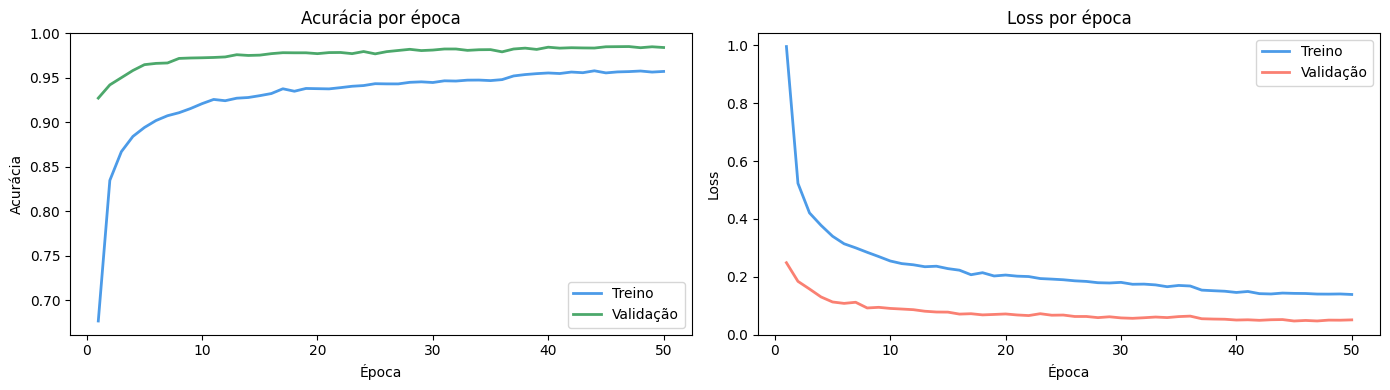

Melhor acurácia (validação): 0.9850


In [13]:
# Curvas de acurácia e loss por época
# Um gap pequeno entre treino e validação indica boa generalização
acc, val_acc   = historico.history['accuracy'], historico.history['val_accuracy']
loss, val_loss = historico.history['loss'], historico.history['val_loss']
epocas         = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epocas, acc,     label='Treino',    color='#4C9BE8', lw=2)
axes[0].plot(epocas, val_acc, label='Validação', color='#4CA86B', lw=2)
axes[0].set_title('Acurácia por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()

axes[1].plot(epocas, loss,     label='Treino',    color='#4C9BE8', lw=2)
axes[1].plot(epocas, val_loss, label='Validação', color='salmon',  lw=2)
axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Melhor acurácia (validação): {max(val_acc):.4f}')

In [14]:
# Relatório de classificação por dígito
# argmax converte as probabilidades da saída Softmax no índice da classe mais provável
y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
y_true = np.argmax(y_val, axis=1)

print(f'Acurácia na validação: {(y_pred == y_true).mean():.4f}')
print()
print(classification_report(y_true, y_pred,
                              target_names=[str(i) for i in range(10)]))

Acurácia na validação: 0.9850

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       816
           1       0.99      1.00      0.99       909
           2       0.99      0.99      0.99       846
           3       0.99      0.98      0.98       937
           4       0.98      0.98      0.98       839
           5       0.97      0.98      0.98       702
           6       0.98      0.99      0.99       785
           7       0.98      0.99      0.99       893
           8       0.99      0.98      0.98       835
           9       0.98      0.97      0.98       838

    accuracy                           0.98      8400
   macro avg       0.98      0.98      0.98      8400
weighted avg       0.99      0.98      0.98      8400



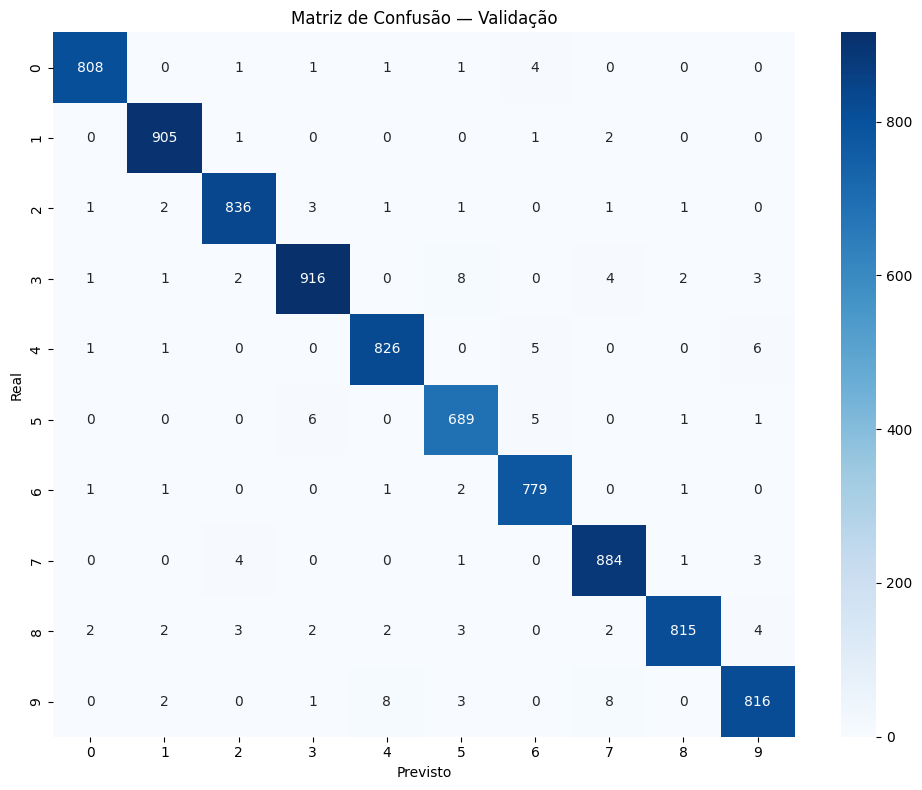

In [15]:
# Matriz de confusão
# Cada célula [i, j] indica quantas vezes o dígito real i foi previsto como j
# A diagonal principal representa as classificações corretas
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusão — Validação')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

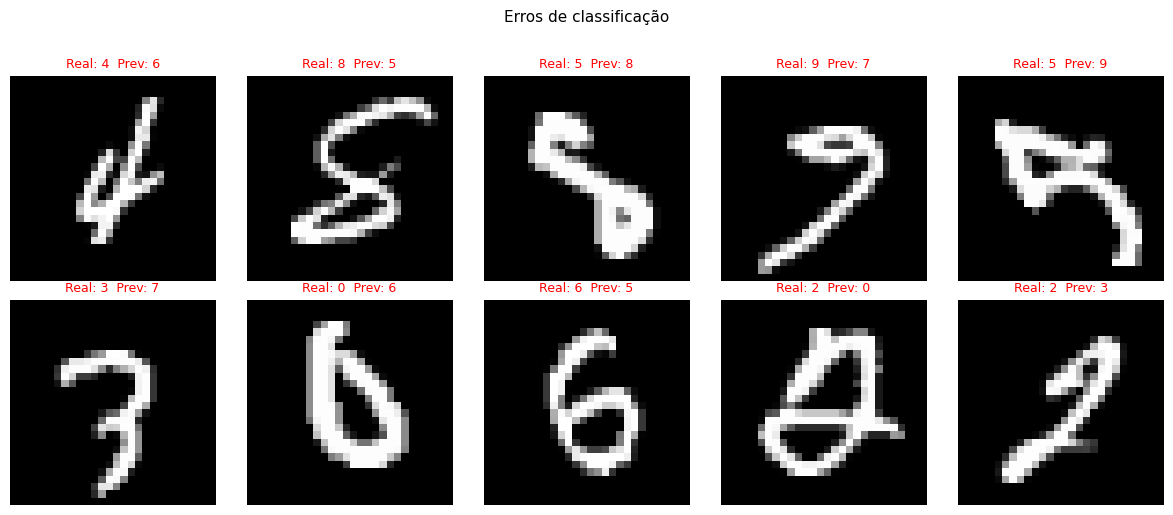

In [16]:
# Visualizar exemplos classificados incorretamente
# Os erros tendem a ser ambíguos visualmente — casos onde humanos também poderiam errar
erros_idx = np.where(y_pred != y_true)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < len(erros_idx):
        idx = erros_idx[i]
        ax.imshow(X_val[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'Real: {y_true[idx]}  Prev: {y_pred[idx]}',
                     fontsize=9, color='red')
        ax.axis('off')
plt.suptitle('Erros de classificação', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 9. Submissão

Para a submissão final, o modelo é retreinado com **todos os 42.000 exemplos** de treino  
(sem reservar validação), pelo mesmo número de épocas que convergiu no experimento anterior.  
Isso maximiza a quantidade de dados disponíveis para o modelo aprender.

In [17]:
# Usar o número de épocas que convergiu no experimento anterior
n_epocas = len(historico.history['accuracy'])

model_final = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax'),
])

model_final.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_final.fit(
    datagen.flow(X, y_cat, batch_size=64),
    epochs=n_epocas,
    steps_per_epoch=len(X) // 64,
    verbose=1
)

print(f'Modelo retreinado com {len(X):,} imagens.')

Epoch 1/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.7012 - loss: 0.9312
Epoch 2/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 19us/step - accuracy: 0.8125 - loss: 0.6173 
Epoch 3/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.8483 - loss: 0.4804
Epoch 4/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 31us/step - accuracy: 0.8906 - loss: 0.3619 
Epoch 5/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.8769 - loss: 0.3915
Epoch 6/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 20us/step - accuracy: 0.8750 - loss: 0.3342 
Epoch 7/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.8897 - loss: 0.3521
Epoch 8/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 18us/step - accuracy: 0.9375 - loss: 0.1653 
Epoch 9/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.8997 - loss: 0.3199
Epoch 10/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 23us/step - accuracy: 0.9062 - loss: 0.3210 
Epoch 11/50
656/656 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.9101 - loss: 0.2914
Epoch 12/50
656/656 ━━━━━━━━━━

In [18]:
# Gerar previsões para o conjunto de teste e salvar no formato exigido pela competição
pred_label = np.argmax(model_final.predict(X_test_final, verbose=0), axis=1)

submission = pd.DataFrame({
    'ImageId': range(1, len(pred_label) + 1),
    'Label':   pred_label
})
submission.to_csv('submission.csv', index=False)

print(f'submission.csv gerado com {len(submission):,} previsões')
submission.head(10)

submission.csv gerado com 28,000 previsões


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
5,6,7
6,7,0
7,8,3
8,9,0
9,10,3


## 10. Conclusão

O modelo MLP treinado com Data Augmentation atingiu **98,089% de acurácia** no Kaggle,
demonstrando que redes neurais densas são suficientes para classificar dígitos manuscritos
com alto desempenho, sem necessidade de arquiteturas convolucionais.

Os principais fatores que contribuíram para o resultado:

- **Data Augmentation:** geração de variações sintéticas reduziu o overfitting e melhorou a generalização
- **BatchNormalization:** estabilizou o treino e acelerou a convergência
- **Dropout decrescente:** regularização adequada em cada camada sem penalizar demais as representações mais abstratas
- **EarlyStopping + ReduceLROnPlateau:** evitaram overfitting e ajustaram o learning rate automaticamente